# Statistics of NMRlipids databank

This notebook plots:
1. Distributions of simulation lengths, number of atoms and trajectory sizes
2. Distribution of number of lipid components
3. Available single component bilayers and binary lipid mixtures
4. Pie diagram of temperatures

# Initializing databank

In [28]:
from DatabankLib.protein_functions import *
import yaml

databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"

#databankPath = "/home/sosamuli/work/NMRlipids/IDPsimBank/"  # this is the local path for the cloned Databank
#os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPsimBank/"



# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()


Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations


# Plot distributions of simulation lengths, number of atoms and trajectory sizes

Number of entries:  459
Folded proteins:  40  simulations,  5  unique sequences
Unfolded proteins:  276  simulations,  27  unique sequences
Partially folded:  140  simulations,  18  unique sequences
Total size of trajectories:  521.483686260879 Gb
Total time of trajectories:  644954.97 ns


Text(0, 0.5, 'Distribution')

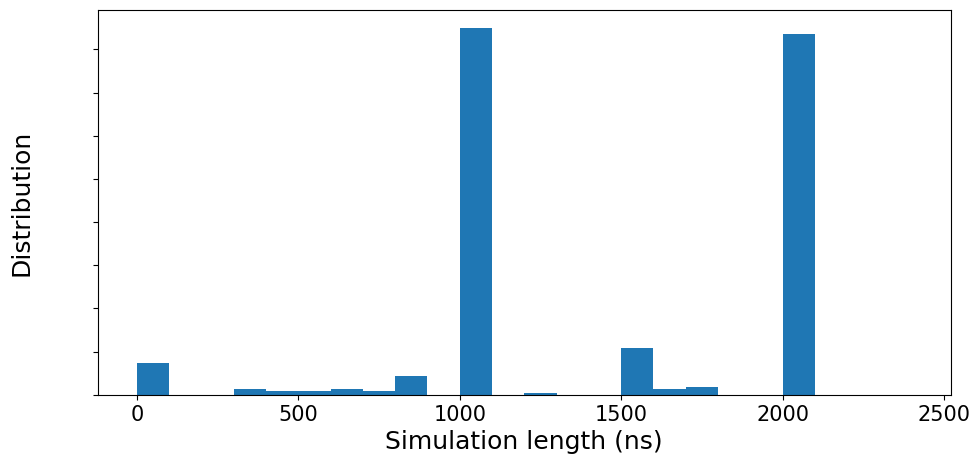

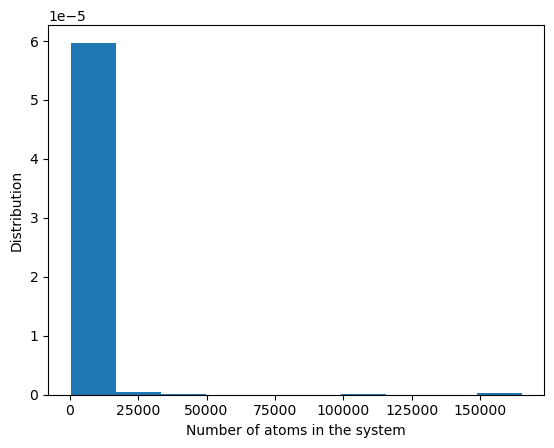

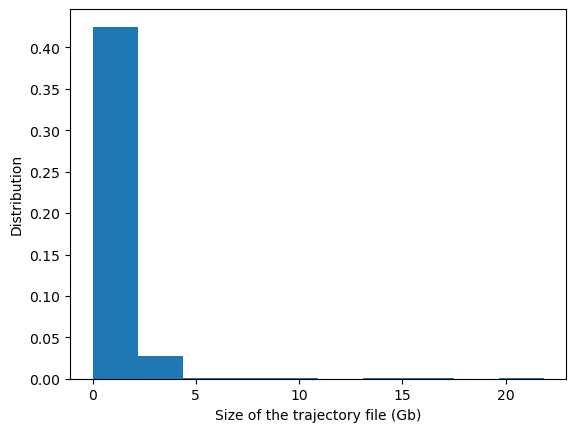

In [36]:
SimulationLengths = []
NumberOfAtoms = []
SizeOfTrajectories = []

protein_classes = {}

# Loop over simulations in the Databank
for system in systems:
    SimulationLengths.append(system['TRJLENGTH']*0.001)
    NumberOfAtoms.append(system['NUMBER_OF_ATOMS'])
    SizeOfTrajectories.append(system['TRAJECTORY_SIZE']/(1024*1024*1024))
    protein_class = protein_folding_class(system, databankPath)
    if protein_class not in protein_classes:
        protein_classes[protein_class] = []
    protein_classes[protein_class].append(system['COMPOSITION']['PROTEIN']['SEQUENCE'])
    #print(protein_class)
    
print("Number of entries: ",len(systems))
print("Folded proteins: ",len(protein_classes['folded'])," simulations, ",len(list(set(protein_classes['folded']))), " unique sequences")
print("Unfolded proteins: ",len(protein_classes['unfolded'])," simulations, ",len(list(set(protein_classes['unfolded']))), " unique sequences")
print("Partially folded: ",len(protein_classes['partially_folded'])," simulations, ",len(list(set(protein_classes['partially_folded']))), " unique sequences")
#    )
print("Total size of trajectories: ",str(np.sum(SizeOfTrajectories)) + ' Gb')
print("Total time of trajectories: ",str(np.sum(SimulationLengths)) + ' ns')

plt.figure(figsize=(11,5))
distSIMl = plt.hist(SimulationLengths, density=True,bins=np.arange(0,2500,100))
plt.xlabel('Simulation length (ns)', fontsize=18)
plt.ylabel('Distribution', fontsize=18)
plt.yticks(color='w')
plt.xticks(fontsize=15)
plt.figure()
distNatoms = plt.hist(NumberOfAtoms, density=True)
plt.xlabel('Number of atoms in the system')
plt.ylabel('Distribution')
plt.figure()
disttrjSIZE = plt.hist(SizeOfTrajectories, density=True)
plt.xlabel('Size of the trajectory file (Gb)')
plt.ylabel('Distribution')

# Available experimental data

In [31]:
from pathlib import Path
from collections import defaultdict
import json
import re
import shlex
import time
import urllib.error
import urllib.parse
import urllib.request

import pandas as pd


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

SPIN_RELAXATION_DIR = Path(
    "../../Data/Experiments/spin_relaxation"
).resolve()

OUTPUT_CSV = Path("spin_relaxation_systems.csv")

DOWNLOAD_MISSING_BMRB_FILES = True
FETCH_DOI_TITLES = True
REQUEST_TIMEOUT = 30

BMRB_URL = "https://bmrb.io/rest/bmrb/{bmrb_id}/nmr-star3"
CROSSREF_URL = "https://api.crossref.org/works/{doi}"


# ---------------------------------------------------------------------
# Dataset identifier handling
# ---------------------------------------------------------------------

def normalize_path(path):
    return str(path).replace("\\", "/").rstrip("/")


def extract_bmrb_number(text):
    """
    Extract the numeric part of a BMRB identifier.

    Examples
    --------
    BMRBid16845 -> 16845
    /path/BMRBid16845/example.str -> 16845
    """
    match = re.search(
        r"BMRBid(\d+)",
        str(text),
        flags=re.IGNORECASE,
    )

    return match.group(1) if match else None


def format_bmrb_id(bmrb_number):
    return f"BMRBid{bmrb_number}"


def experiment_identifier(path):
    """
    Convert an experiment path into BMRBidXXXXX or DOI.

    Examples
    --------
    ../../Data/Experiments/spin_relaxation/BMRBid16845
        -> BMRBid16845

    ../../Data/Experiments/spin_relaxation/10.1016/example
        -> 10.1016/example
    """
    path = normalize_path(path)
    marker = "/spin_relaxation/"

    if marker in path:
        identifier = path.split(marker, 1)[1]
    else:
        identifier = path

    identifier = identifier.strip("/")

    bmrb_number = extract_bmrb_number(identifier)

    if bmrb_number:
        return format_bmrb_id(bmrb_number)

    return identifier


# ---------------------------------------------------------------------
# Information from systems
# ---------------------------------------------------------------------

def get_spin_relaxation_paths(system):
    try:
        paths = system["EXPERIMENT"]["spin_relaxation"]["path"]
    except (KeyError, TypeError):
        return []

    if paths is None:
        return []

    if isinstance(paths, (list, tuple, set)):
        return [
            str(path)
            for path in paths
            if path is not None
        ]

    return [str(paths)]


def get_system_sequence(system):
    try:
        return system["COMPOSITION"]["PROTEIN"]["SEQUENCE"]
    except (KeyError, TypeError):
        return None


def sequence_length(sequence):
    """
    Calculate sequence length.

    Supports strings, FASTA-formatted strings, lists, tuples,
    sets, and dictionaries. Lengths of multiple chains are summed.
    """
    if sequence is None:
        return None

    if isinstance(sequence, str):
        sequence_lines = [
            line.strip()
            for line in sequence.splitlines()
            if line.strip() and not line.lstrip().startswith(">")
        ]

        sequence = "".join(sequence_lines)
        sequence = re.sub(r"[^A-Za-z]", "", sequence)

        return len(sequence) if sequence else None

    if isinstance(sequence, dict):
        lengths = [
            sequence_length(value)
            for value in sequence.values()
        ]
    elif isinstance(sequence, (list, tuple, set)):
        lengths = [
            sequence_length(value)
            for value in sequence
        ]
    else:
        return sequence_length(str(sequence))

    lengths = [
        length
        for length in lengths
        if length is not None
    ]

    return sum(lengths) if lengths else None


def collect_simulation_information(systems):
    """
    Determine which datasets have simulations.

    For DOI datasets, also collect sequence lengths from systems.
    BMRB sequence lengths are not taken from systems.
    """
    simulation_identifiers = set()
    doi_lengths = defaultdict(set)

    for system in systems:
        paths = get_spin_relaxation_paths(system)

        if not paths:
            continue

        system_length = sequence_length(
            get_system_sequence(system)
        )

        for path in paths:
            identifier = experiment_identifier(path)

            if not identifier:
                continue

            simulation_identifiers.add(identifier)

            # DOI sequence lengths come from systems.
            if extract_bmrb_number(identifier) is None:
                if system_length is not None:
                    doi_lengths[identifier].add(system_length)

    resolved_doi_lengths = {}

    for identifier, lengths in doi_lengths.items():
        sorted_lengths = sorted(lengths)

        if len(sorted_lengths) > 1:
            print(
                f"WARNING: {identifier} is associated with "
                f"multiple sequence lengths: {sorted_lengths}. "
                f"Using the shortest length."
            )

        resolved_doi_lengths[identifier] = (
            sorted_lengths[0] if sorted_lengths else None
        )

    return simulation_identifiers, resolved_doi_lengths


# ---------------------------------------------------------------------
# BMRB file handling
# ---------------------------------------------------------------------

def find_bmrb_directories(root_directory):
    """
    Find top-level BMRBidXXXXX directories.
    """
    directories = {}

    for directory in root_directory.iterdir():
        if not directory.is_dir():
            continue

        bmrb_number = extract_bmrb_number(directory.name)

        if bmrb_number:
            directories[
                format_bmrb_id(bmrb_number)
            ] = directory

    return directories


def find_local_str_file(bmrb_directory):
    bmrb_number = extract_bmrb_number(
        bmrb_directory.name
    )

    preferred_files = [
        bmrb_directory / f"bmr{bmrb_number}_3.str",
        bmrb_directory / f"bmr{bmrb_number}.str",
    ]

    for candidate in preferred_files:
        if candidate.is_file():
            return candidate

    str_files = sorted(bmrb_directory.rglob("*.str"))

    return str_files[0] if str_files else None


def download_bmrb_str(bmrb_number, bmrb_directory):
    bmrb_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    output_file = (
        bmrb_directory / f"bmr{bmrb_number}_3.str"
    )

    url = BMRB_URL.format(bmrb_id=bmrb_number)

    request = urllib.request.Request(
        url,
        headers={
            "User-Agent": "spin-relaxation-table/1.0"
        },
    )

    try:
        with urllib.request.urlopen(
            request,
            timeout=REQUEST_TIMEOUT,
        ) as response:
            content = response.read()

        if not content.strip():
            print(
                f"WARNING: Empty response for "
                f"BMRBid{bmrb_number}"
            )
            return None

        output_file.write_bytes(content)

        print(f"Downloaded BMRBid{bmrb_number}")

        return output_file

    except (
        urllib.error.HTTPError,
        urllib.error.URLError,
        TimeoutError,
        OSError,
    ) as error:
        print(
            f"WARNING: Could not download "
            f"BMRBid{bmrb_number}: {error}"
        )
        return None


def get_bmrb_str_file(
    bmrb_directory,
    download_missing=True,
):
    str_file = find_local_str_file(bmrb_directory)

    if str_file is not None:
        return str_file

    if not download_missing:
        return None

    bmrb_number = extract_bmrb_number(
        bmrb_directory.name
    )

    if bmrb_number is None:
        return None

    return download_bmrb_str(
        bmrb_number,
        bmrb_directory,
    )


# ---------------------------------------------------------------------
# Basic NMR-STAR parser
# ---------------------------------------------------------------------

def tokenize_star_file(str_file):
    """
    Tokenize the parts of an NMR-STAR file needed for this table.

    Handles:
      * quoted fields
      * comments
      * semicolon-delimited multiline fields
      * loop_ blocks
    """
    text = str_file.read_text(
        encoding="utf-8",
        errors="replace",
    )

    lines = text.splitlines()
    tokens = []
    line_index = 0

    while line_index < len(lines):
        line = lines[line_index]

        # Semicolon-delimited multiline field.
        if line.startswith(";"):
            value_lines = []

            if len(line) > 1:
                value_lines.append(line[1:])

            line_index += 1

            while line_index < len(lines):
                if lines[line_index].startswith(";"):
                    break

                value_lines.append(lines[line_index])
                line_index += 1

            tokens.append(
                "\n".join(value_lines).strip()
            )

            line_index += 1
            continue

        stripped = line.strip()

        if not stripped or stripped.startswith("#"):
            line_index += 1
            continue

        lexer = shlex.shlex(
            stripped,
            posix=True,
        )

        lexer.whitespace_split = True
        lexer.commenters = "#"

        try:
            tokens.extend(list(lexer))
        except ValueError:
            tokens.extend(stripped.split())

        line_index += 1

    return tokens


def clean_star_value(value):
    if value is None:
        return ""

    value = str(value).strip()

    if value in {"", ".", "?"}:
        return ""

    return " ".join(value.split())


def get_star_scalar(tokens, tag_name):
    """
    Get the value following a scalar NMR-STAR tag.
    """
    tag_name = tag_name.lower()

    for index, token in enumerate(tokens[:-1]):
        if token.lower() == tag_name:
            return clean_star_value(tokens[index + 1])

    return ""


def read_star_loops(tokens):
    """
    Yield each NMR-STAR loop as:

        tags, rows
    """
    index = 0

    while index < len(tokens):
        if tokens[index].lower() != "loop_":
            index += 1
            continue

        index += 1
        tags = []

        while (
            index < len(tokens)
            and tokens[index].startswith("_")
        ):
            tags.append(tokens[index])
            index += 1

        if not tags:
            continue

        values = []

        while index < len(tokens):
            token = tokens[index]
            token_lower = token.lower()

            if token_lower in {"stop_", "loop_", "save_"}:
                break

            if token_lower.startswith("save_"):
                break

            values.append(token)
            index += 1

        number_of_columns = len(tags)

        rows = []

        for start in range(
            0,
            len(values),
            number_of_columns,
        ):
            row = values[
                start:start + number_of_columns
            ]

            if len(row) == number_of_columns:
                rows.append(row)

        yield tags, rows

        if (
            index < len(tokens)
            and tokens[index].lower() == "stop_"
        ):
            index += 1


# ---------------------------------------------------------------------
# BMRB title and sequence extraction
# ---------------------------------------------------------------------

def extract_bmrb_metadata(str_file):
    """
    Extract the BMRB entry title and protein sequence length.

    Sequence lengths are calculated from _Entity_poly_seq loops.
    Residues are grouped by Entity_ID to avoid mixing different
    polymer entities.
    """
    tokens = tokenize_star_file(str_file)

    title = get_star_scalar(
        tokens,
        "_Entry.Title",
    )

    entity_residues = defaultdict(set)

    for tags, rows in read_star_loops(tokens):
        lower_tags = [
            tag.lower()
            for tag in tags
        ]

        if "_entity_poly_seq.num" not in lower_tags:
            continue

        residue_number_index = lower_tags.index(
            "_entity_poly_seq.num"
        )

        if "_entity_poly_seq.entity_id" in lower_tags:
            entity_id_index = lower_tags.index(
                "_entity_poly_seq.entity_id"
            )
        else:
            entity_id_index = None

        for row in rows:
            residue_number = clean_star_value(
                row[residue_number_index]
            )

            if not residue_number:
                continue

            if entity_id_index is None:
                entity_id = "1"
            else:
                entity_id = clean_star_value(
                    row[entity_id_index]
                ) or "1"

            entity_residues[entity_id].add(
                residue_number
            )

    entity_lengths = {
        entity_id: len(residue_numbers)
        for entity_id, residue_numbers
        in entity_residues.items()
    }

    total_sequence_length = (
        sum(entity_lengths.values())
        if entity_lengths
        else None
    )

    return {
        "title": title,
        "sequence_length": total_sequence_length,
        "entity_lengths": entity_lengths,
    }


# ---------------------------------------------------------------------
# DOI article titles
# ---------------------------------------------------------------------

def normalize_doi(identifier):
    doi = str(identifier).strip().strip("/")

    doi = re.sub(
        r"^https?://(?:dx\.)?doi\.org/",
        "",
        doi,
        flags=re.IGNORECASE,
    )

    return doi


def fetch_doi_title(doi):
    """
    Try to fetch the article title from Crossref.

    Returns an empty string if no title can be retrieved.
    """
    doi = normalize_doi(doi)

    if not doi:
        return ""

    encoded_doi = urllib.parse.quote(
        doi,
        safe="",
    )

    url = CROSSREF_URL.format(doi=encoded_doi)

    request = urllib.request.Request(
        url,
        headers={
            "User-Agent": "spin-relaxation-table/1.0"
        },
    )

    try:
        with urllib.request.urlopen(
            request,
            timeout=REQUEST_TIMEOUT,
        ) as response:
            result = json.load(response)

        titles = (
            result
            .get("message", {})
            .get("title", [])
        )

        if not titles:
            return ""

        return clean_star_value(titles[0])

    except (
        urllib.error.HTTPError,
        urllib.error.URLError,
        TimeoutError,
        OSError,
        json.JSONDecodeError,
    ) as error:
        print(
            f"WARNING: Could not retrieve title "
            f"for {doi}: {error}"
        )
        return ""


# ---------------------------------------------------------------------
# Build the table
# ---------------------------------------------------------------------

def build_spin_relaxation_table(
    systems,
    spin_relaxation_directory=SPIN_RELAXATION_DIR,
    download_missing_bmrb_files=True,
    fetch_doi_titles=True,
):
    if not spin_relaxation_directory.is_dir():
        raise FileNotFoundError(
            f"Directory not found: "
            f"{spin_relaxation_directory}"
        )

    (
        simulation_identifiers,
        doi_sequence_lengths,
    ) = collect_simulation_information(systems)

    bmrb_directories = find_bmrb_directories(
        spin_relaxation_directory
    )

    # Include all local BMRB datasets and all datasets referenced
    # by systems. The latter also includes DOI datasets.
    all_identifiers = (
        set(bmrb_directories)
        | simulation_identifiers
    )

    rows = []

    for identifier in all_identifiers:
        simulation_available = (
            identifier in simulation_identifiers
        )

        bmrb_number = extract_bmrb_number(identifier)

        if bmrb_number is not None:
            identifier = format_bmrb_id(bmrb_number)

            bmrb_directory = bmrb_directories.get(
                identifier,
                spin_relaxation_directory / identifier,
            )

            str_file = get_bmrb_str_file(
                bmrb_directory,
                download_missing=(
                    download_missing_bmrb_files
                ),
            )

            title = ""
            length = None

            if str_file is not None:
                try:
                    metadata = extract_bmrb_metadata(
                        str_file
                    )

                    title = metadata["title"]
                    length = metadata["sequence_length"]

                    if len(metadata["entity_lengths"]) > 1:
                        print(
                            f"{identifier}: polymer entity "
                            f"lengths "
                            f"{metadata['entity_lengths']}; "
                            f"total = {length}"
                        )

                except Exception as error:
                    print(
                        f"WARNING: Could not parse "
                        f"{str_file}: {error}"
                    )

        else:
            # DOI dataset
            length = doi_sequence_lengths.get(identifier)

            if fetch_doi_titles:
                title = fetch_doi_title(identifier)
                time.sleep(0.1)
            else:
                title = ""

        rows.append(
            {
                "BMRBid or DOI": identifier,
                "Title": title,
                "Simulation available": (
                    "Yes"
                    if simulation_available
                    else "No"
                ),
                "Sequence length": length,
            }
        )

    df = pd.DataFrame(
        rows,
        columns=[
            "BMRBid or DOI",
            "Title",
            "Simulation available",
            "Sequence length",
        ],
    )

    # Allow integer values and missing values in the same column.
    df["Sequence length"] = pd.to_numeric(
        df["Sequence length"],
        errors="coerce",
    ).astype("Int64")

    # Yes = 0 and No = 1, so simulation systems come first.
    df["_simulation_order"] = (
        df["Simulation available"]
        .map({"Yes": 0, "No": 1})
    )

    df = (
        df.sort_values(
            by=[
                "_simulation_order",
                "Sequence length",
                "BMRBid or DOI",
            ],
            ascending=[
                True,
                True,
                True,
            ],
            na_position="last",
        )
        .drop(columns="_simulation_order")
        .reset_index(drop=True)
    )

    return df


# ---------------------------------------------------------------------
# Run
# ---------------------------------------------------------------------

# `systems` is assumed to have already been initialized.

df = build_spin_relaxation_table(
    systems=systems,
    spin_relaxation_directory=SPIN_RELAXATION_DIR,
    download_missing_bmrb_files=(
        DOWNLOAD_MISSING_BMRB_FILES
    ),
    fetch_doi_titles=FETCH_DOI_TITLES,
)

# Save the sorted table.
df.to_csv(
    OUTPUT_CSV,
    index=False,
)

# Display the complete pandas table in Jupyter.
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

#display(df)

print()
print(f"Number of datasets: {len(df)}")
print(
    "Datasets with simulations: "
    f"{(df['Simulation available'] == 'Yes').sum()}"
)
print(
    "Datasets without simulations: "
    f"{(df['Simulation available'] == 'No').sum()}"
)
print(
    "Datasets with known sequence length: "
    f"{df['Sequence length'].notna().sum()}"
)
print(f"Saved table to: {OUTPUT_CSV.resolve()}")

BMRBid50494: polymer entity lengths {'1': 102, '2': 106}; total = 208
BMRBid17080: polymer entity lengths {'1': 211, '2': 27}; total = 238
BMRBid16483: polymer entity lengths {'1': 80, '2': 23}; total = 103
BMRBid5153: polymer entity lengths {'1': 126, '2': 173}; total = 299
BMRBid50243: polymer entity lengths {'1': 75, '2': 350}; total = 425
BMRBid6474: polymer entity lengths {'1': 139, '2': 13}; total = 152
BMRBid18461: polymer entity lengths {'1': 172, '5': 79}; total = 251
BMRBid16485: polymer entity lengths {'1': 87, '2': 32}; total = 119
BMRBid6881: polymer entity lengths {'1': 35, '2': 241}; total = 276
BMRBid51413: polymer entity lengths {'1': 417, '2': 16}; total = 433
BMRBid6092: polymer entity lengths {'1': 102, '2': 12}; total = 114
BMRBid27594: polymer entity lengths {'1': 243, '2': 152}; total = 395
BMRBid51415: polymer entity lengths {'1': 125, '2': 16}; total = 141
BMRBid7415: polymer entity lengths {'1': 159, '2': 1}; total = 160
BMRBid26742: polymer entity lengths {'1

In [32]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

df = pd.read_csv("/home/sosamuli/work/NMRlipids/IDPdatabank/Scripts/AnalyzeDatabank/spin_relaxation_systems.csv")

display(df)

,BMRBid or DOI,Title,Simulation available,Sequence length
0,BMRBid50115,"Backbone 13C, and 15N Chemical Shift Assignments for ChiZ N-terminal Domain",Yes,67
1,BMRBid19993,Lysyl t-RNA synthetase 1-72,Yes,72
2,10.1021/acs.jpcb.8b02250,Rotational Dynamics of Proteins from Spin Relaxation Times and Molecular Dynamics Simulations,Yes,92
3,10.7717/peerj.5412,NMR structure of the C-terminal domain of TonB protein from <i>Pseudomonas aeruginosa</i>,Yes,99
4,BMRBid27321,"1H, 13C and 15N Chemical Shift Assignments and 15N backbone relaxation data for intracellular loop 2 of the human ZIP4 protein",Yes,100
5,10.1016/j.bpj.2015.06.069,Distribution of Pico- and Nanosecond Motions in Disordered Proteins from Nuclear Spin Relaxation,Yes,117
6,10.1074/jbc.m106777200,Residual Structure and Dynamics in Parkinson's Disease-associated Mutants of α-Synuclein,Yes,140
7,BMRBid51529,Relaxation parameters of calcium loaded human calmodulin at pH 7.0 and 37degC (600 MHz),Yes,148
8,BMRBid19164,solution structure of cerebral dopamine neurotrophic factor (CDNF),Yes,161
9,10.1016/j.febslet.2010.03.008,Solution structure and dynamics of mouse ARMET,Yes,171


In [35]:
for system in systems:
    print(system['EXPERIMENT']['saxs'])

{'alignment_score': [], 'ionic_strength': [], 'ionic_strength_match': [], 'path': [], 'ph': [], 'ph_match': [], 'sequence': [], 'temperature': [], 'temperature_match': []}
{'alignment_score': [], 'ionic_strength': [], 'ionic_strength_match': [], 'path': [], 'ph': [], 'ph_match': [], 'sequence': [], 'temperature': [], 'temperature_match': []}
{'alignment_score': [670.0, 670.0, 670.0], 'ionic_strength': [0.05, 0.15, 0.05], 'ionic_strength_match': [False, True, False], 'path': ['SASDQK7', '10.1038/srep30473', 'SASDQJ7'], 'ph': [7.4, 7.5, 7.4], 'ph_match': [True, True, True], 'sequence': ['MDVFMKGLSKAKEGVVAAAEKTKQGVAEAAGKTKEGVLYVGSKTKEGVVHGVATVAEKTKEQVTNVGGAVVTGVTAVAQKTVEGAGSIAAATGFVKKDQLGKNEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA', 'MDVFMKGLSKAKEGVVAAAEKTKQGVAEAAGKTKEGVLYVGSKTKEGVVHGVATVAEKTKEQVTNVGGAVVTGVTAVAQKTVEGAGSIAAATGFVKKDQLGKNEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA', 'MDVFMKGLSKAKEGVVAAAEKTKQGVAEAAGKTKEGVLYVGSKTKEGVVHGVATVAEKTKEQVTNVGGAVVTGVTAVAQKTVEGAGSIAAATGFVKKDQLGKNEEGAPQEGILEDMPVD

# Plot distribution of different proteins

{'Charged sequence with tris': 3, 'KRS1-72_salt': 25, 'asyn_salt': 25, 'SNAP25_noions': 24, 'CDNF': 25, 'KRS1-72': 25, 'wrapping silk (AcSp1)': 25, 'Protein linker': 7, 'asyn': 25, 'ChiZ_salt': 25, 'ChiZ1-64': 25, 'Charged sequence with NaCl': 6, 'md_TonB_linkerAP_deprot_40mm': 1, 'calmodulin': 25, 'md_EEVKP40_deprot': 1, 'silk protein': 67, 'MANF': 25, 'TonBCTD': 25, 'icl2': 25, 'EN2': 25, 'yibk linear no salt': 1, 'Charged protonated sequence with CaCl': 1, 'md_TonB_linkerKP_deprot_40mm': 1, 'Charged sequence with NaCl and phosphate': 2, 'yibk cyclic 40mM NaCl': 1, 'md_TonB_31-111_protonated': 1, 'PsTonB': 1, 'md_TonB_linkerKP_prot_40mm': 1, 'Charged sequence with CaCl': 1, 'yibk cyclic no salt': 1, 'md_EEVKP40_prot': 1, 'Charged protonated sequence with NaCl': 1, 'Charged sequence with CaCl and phosphate': 1, 'TonB': 1, 'Charged sequence protonated peptide': 1, 'TonB low pH with CaCl': 1, 'md_TonB_linkerAP_prot_40mm': 1, 'Charged sequence peptide': 1, 'md_TonB_31-111_deprot_40mm': 1

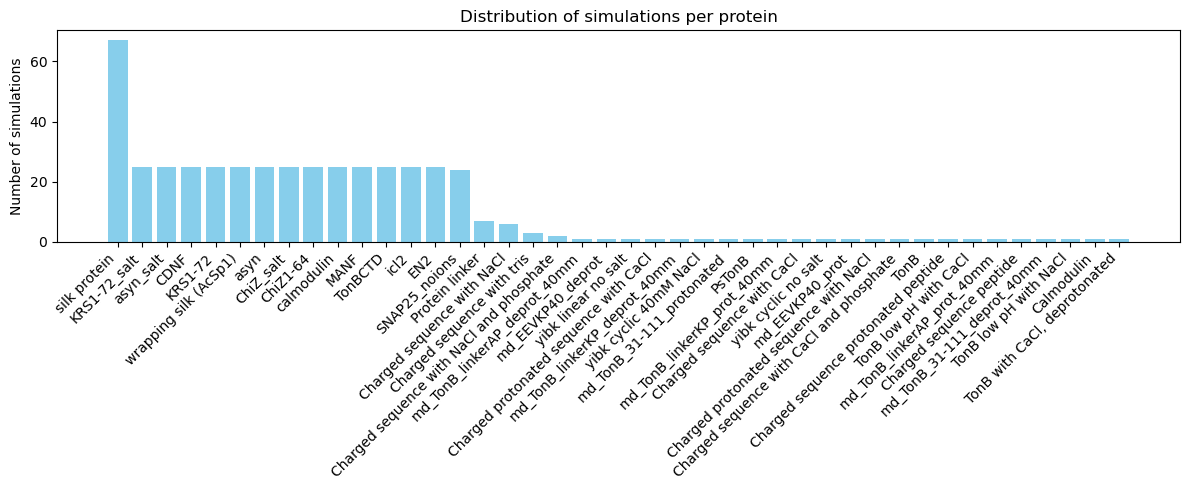

In [3]:
# Loop over simulations in the Databank

system_descriptions = {}

for system in systems:
    #print(system['COMPOSITION']['PROTEIN']['SEQUENCE'])
    system_description = system['SYSTEM']
    if system_description not in system_descriptions:
        system_descriptions[system_description] = 1
    else:
        system_descriptions[system_description] += 1
    
    #print(system['FF'])
print(system_descriptions)
    
# Your dictionary
protein_counts = system_descriptions

# Sort by counts (optional)
sorted_items = dict(sorted(protein_counts.items(), key=lambda x: x[1], reverse=True))

# Create bar plot
plt.figure(figsize=(12,5))
plt.bar(sorted_items.keys(), sorted_items.values(), color='skyblue')

plt.ylabel("Number of simulations")
plt.title("Distribution of simulations per protein")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Show available simulations for Uniprot IDs

In [4]:
import re
import yaml
import pandas as pd
from collections import defaultdict

# -----------------------------
# helpers
# -----------------------------

def parse_uniprot(title):
    uid = re.search(r'\|([^|]+)\|', title)
    name = re.search(r'RecName: Full=([^;]+)', title)

    return (
        uid.group(1) if uid else "",
        name.group(1) if name else ""
    )

def has_data(block):
    """
    True if any list in experiment block is non-empty
    """
    if not isinstance(block, dict):
        return False

    for v in block.values():
        if isinstance(v, list) and len(v) > 0:
            return True
    return False

def yesno(x):
    return "Yes" if x else "No"

# -----------------------------
# grouping
# -----------------------------

groups = defaultdict(lambda: {
    "system_ids": [],
    "chemical_shift": False,
    "saxs": False,
    "spin_relaxation": False
})

# -----------------------------
# loop over systems
# -----------------------------

for system in systems:
    path = databankPath + 'Data/Simulations/' + system['path'] + 'cross_link_data.yaml'

    try:
        with open(path) as f:
            data = yaml.safe_load(f)
    except Exception:
        continue

    uniprot_hits = data.get("uniprot", [])
    if not uniprot_hits:
        continue

    best = max(uniprot_hits, key=lambda x: x["similarity_%"])
    uid, pname = parse_uniprot(best["title"])
    sim = best["similarity_%"]

    key = (uid, pname, sim)

    groups[key]["system_ids"].append(system["ID"])

    # -----------------------------
    # experiments
    # -----------------------------
    exp = system.get("EXPERIMENT", {})

    groups[key]["chemical_shift"] |= has_data(exp.get("chemical_shift", {}))
    groups[key]["saxs"] |= has_data(exp.get("saxs", {}))
    groups[key]["spin_relaxation"] |= has_data(exp.get("spin_relaxation", {}))

# -----------------------------
# build dataframe
# -----------------------------

rows = []

for (uid, pname, sim), v in groups.items():
    rows.append({
        "UniProt ID": uid,
        "Protein name": pname,
        "System IDs": ", ".join(map(str, v["system_ids"])),
        "Similarity (%)": sim,
        "Chemical shift": yesno(v["chemical_shift"]),
        "SAXS": yesno(v["saxs"]),
        "Spin relaxation": yesno(v["spin_relaxation"]),
    })

df = pd.DataFrame(rows)

# optional sorting
df = df.sort_values(
    ["Protein name", "Similarity (%)"],
    ascending=[True, False]
)

df



,UniProt ID,Protein name,System IDs,Similarity (%),Chemical shift,SAXS,Spin relaxation
7,P37840.1,Alpha-synuclein,"53, 104, 106, 57, 61, 62, 63, 66, 110, 112, 71...",100.00,Yes,Yes,Yes
2,P37377.1,Alpha-synuclein [Rattus norvegicus],"103, 109, 65, 73, 74, 113, 114, 118, 123, 88, ...",100.00,Yes,Yes,Yes
6,P37377.1,Alpha-synuclein [Rattus norvegicus],"52, 105, 111, 69, 76, 117, 77, 81, 119, 86, 91...",99.29,Yes,Yes,Yes
17,A0A2R2JFW7.1,Arginase [Glaciozyma antarctica PI12],"327, 329, 330, 333, 338, 340, 341, 344, 346, 3...",100.00,Yes,No,No
9,P0DP23.1,Calmodulin-1 [Homo sapiens] >sp|P0DP24.1| RecN...,"191, 192, 194, 196, 198, 199, 203, 205, 208, 2...",100.00,Yes,No,Yes
11,I6YA32.1,Cell wall hydrolase ChiZ [Mycobacterium tuberc...,"178, 156, 7, 11, 158, 12, 161, 18, 19, 22, 24,...",100.00,No,Yes,Yes
8,I6YA32.1,Cell wall hydrolase ChiZ [Mycobacterium tuberc...,"152, 2, 3, 4, 154, 155, 6, 157, 10, 159, 160, ...",95.31,No,Yes,Yes
4,Q49AH0.2,Cerebral dopamine neurotrophic factor,"323, 328, 288, 331, 332, 289, 290, 299, 339, 3...",100.00,Yes,No,Yes
21,Q49AH0.2,Cerebral dopamine neurotrophic factor,"353, 307, 364, 371, 292",98.14,Yes,No,Yes
16,Q05917.2,Homeobox protein engrailed-2,"410, 415, 416, 417, 405, 406, 411, 418, 407, 4...",100.00,Yes,No,Yes


In [6]:
import matplotlib.pyplot as plt
import textwrap

# -----------------------------
# Helper functions
# -----------------------------

def shorten_name(name, max_words=10, wrap_width=45):
    """Truncate a protein name to max_words and wrap it."""
    words = str(name).split()
    if len(words) > max_words:
        name = " ".join(words[:max_words]) + " ..."
    return "\n".join(textwrap.wrap(name, width=wrap_width))


def compress_ids(ids):
    """
    Convert a list of integers like
    [1,2,3,5,6,8]
    into
    '1-3, 5-6, 8'
    """
    ids = sorted(set(int(i) for i in ids))

    if not ids:
        return ""

    ranges = []
    start = prev = ids[0]

    for n in ids[1:]:
        if n == prev + 1:
            prev = n
        else:
            if start == prev:
                ranges.append(str(start))
            else:
                ranges.append(f"{start}-{prev}")
            start = prev = n

    # Add final range
    if start == prev:
        ranges.append(str(start))
    else:
        ranges.append(f"{start}-{prev}")

    return ", ".join(ranges)


def format_system_ids(system_ids, wrap_width=50):
    """
    Compress consecutive IDs into ranges and wrap the text.
    """
    ids = [int(i.strip()) for i in str(system_ids).split(",")]
    compressed = compress_ids(ids)
    return "\n".join(textwrap.wrap(compressed, width=wrap_width))


# -----------------------------
# Prepare dataframe for plotting
# -----------------------------

df_plot = df.copy()

# Shorten and wrap protein names
df_plot["Protein name"] = df_plot["Protein name"].apply(
    lambda x: shorten_name(x, max_words=10, wrap_width=45)
)

# Compress and wrap System IDs
df_plot["System IDs"] = df_plot["System IDs"].apply(
    lambda x: format_system_ids(x, wrap_width=50)
)

# -----------------------------
# Create figure
# -----------------------------

fig_height = max(4, len(df_plot) * 0.45)

fig, ax = plt.subplots(figsize=(15, fig_height))
ax.axis("off")

table = ax.table(
    cellText=df_plot.values,
    colLabels=df_plot.columns,
    loc="center",
    cellLoc="left"
)

# Font settings
table.auto_set_font_size(False)
table.set_fontsize(8)

# Increase row height
table.scale(1, 2.3)

# -----------------------------
# Column widths
# -----------------------------

col_widths = {
    0: 0.13,  # UniProt ID
    1: 0.32,  # Protein name
    2: 0.28,  # System IDs
    3: 0.08,  # Similarity
    4: 0.08,  # Chemical shift
    5: 0.05,  # SAXS
    6: 0.09,  # Spin relaxation
}

for (row, col), cell in table.get_celld().items():
    if col in col_widths:
        cell.set_width(col_widths[col])

    cell.get_text().set_wrap(True)

    if row == 0:
        cell.set_text_props(weight="bold")

# -----------------------------
# Save
# -----------------------------

plt.savefig("table.pdf", bbox_inches="tight")
plt.close()

print("Saved table to table.pdf")

Saved table to table.pdf


# Show available simulations for PDB IDs

In [46]:
import re
import yaml
import pandas as pd
from collections import defaultdict

# -----------------------------
# helpers
# -----------------------------

def parse_pdb(title):
    pid = re.search(r'pdb\|([^|]+)\|', title)
    name = re.search(r'Chain [A-Z],\s*([^>\[]+)', title)

    return (
        pid.group(1) if pid else "",
        name.group(1).strip() if name else ""
    )

def has_data(block):
    """
    Returns True if experiment block contains any non-empty list.
    """
    if not isinstance(block, dict):
        return False

    for v in block.values():
        if isinstance(v, list) and len(v) > 0:
            return True
    return False

def yesno(x):
    return "Yes" if x else "No"

# -----------------------------
# grouping container
# -----------------------------

groups = defaultdict(lambda: {
    "system_ids": [],
    "chemical_shift": False,
    "saxs": False,
    "spin_relaxation": False
})

# -----------------------------
# main loop
# -----------------------------

for system in systems:
    path = databankPath + 'Data/Simulations/' + system['path'] + 'cross_link_data.yaml'

    try:
        with open(path) as f:
            data = yaml.safe_load(f)
    except Exception:
        continue

    pdb_hits = data.get("pdb", [])
    if not pdb_hits:
        continue

    best = max(pdb_hits, key=lambda x: x["similarity_%"])
    pid, pname = parse_pdb(best["title"])
    sim = best["similarity_%"]

    key = (pid, pname, sim)

    groups[key]["system_ids"].append(system["ID"])

    # -----------------------------
    # experiments
    # -----------------------------
    exp = system.get("EXPERIMENT", {})

    groups[key]["chemical_shift"] |= has_data(exp.get("chemical_shift", {}))
    groups[key]["saxs"] |= has_data(exp.get("saxs", {}))
    groups[key]["spin_relaxation"] |= has_data(exp.get("spin_relaxation", {}))

# -----------------------------
# build dataframe
# -----------------------------

rows = []

for (pid, pname, sim), v in groups.items():
    rows.append({
        "PDB ID": pid,
        "Protein name": pname,
        "System IDs": ", ".join(map(str, v["system_ids"])),
        "Similarity (%)": sim,
        "Chemical shift": yesno(v["chemical_shift"]),
        "SAXS": yesno(v["saxs"]),
        "Spin relaxation": yesno(v["spin_relaxation"]),
    })

df = pd.DataFrame(rows)

# optional sorting
df = df.sort_values(
    ["Protein name", "Similarity (%)"],
    ascending=[True, False]
)

df

,PDB ID,Protein name,System IDs,Similarity (%),Chemical shift,SAXS,Spin relaxation
6,2MU3,Aciniform spidroin 1,"190, 193, 195, 188, 197, 200, 201, 202, 204, 1...",100.00,No,No,No
8,1XQ8,Alpha-synuclein,"53, 104, 106, 57, 61, 62, 63, 66, 110, 112, 71...",100.00,Yes,Yes,Yes
2,8UIE,Alpha-synuclein,"103, 109, 65, 73, 74, 113, 114, 118, 123, 88, ...",99.29,Yes,Yes,Yes
7,8UIE,Alpha-synuclein,"52, 105, 111, 69, 76, 117, 77, 81, 119, 86, 91...",98.57,Yes,Yes,Yes
11,2XFF,BETA-AMYLASE,"324, 293, 294, 325, 295, 326, 296, 297, 298, 3...",55.17,No,No,No
4,4BIT,CEREBRAL DOPAMINE NEUROTROPHIC FACTOR,"323, 328, 288, 331, 332, 289, 290, 299, 339, 3...",100.00,Yes,No,Yes
10,6O20,Calmodulin,"191, 192, 194, 196, 198, 199, 203, 205, 208, 2...",100.00,Yes,No,Yes
19,2LPN,Cerebral dopamine neurotrophic factor,"353, 307, 364, 371",99.05,Yes,No,Yes
16,5ZVL,Glutaredoxin,"327, 329, 330, 333, 338, 340, 341, 344, 346, 3...",97.83,No,No,No
15,3ZOB,HOMEOBOX PROTEIN ENGRAILED-2,"410, 415, 416, 417, 405, 406, 411, 418, 407, 4...",95.31,Yes,No,Yes


# Plot distribution of different force fields

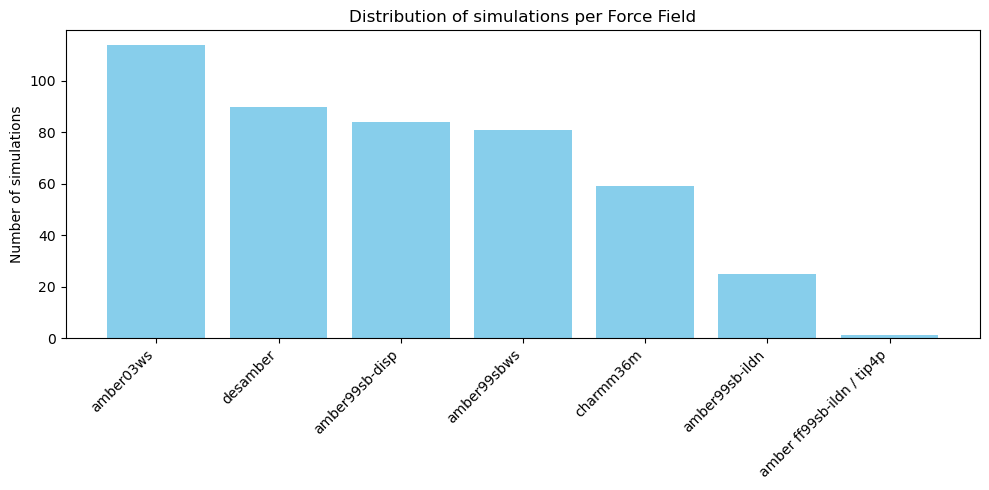

In [5]:
import matplotlib.pyplot as plt

# Mapping of variant names to canonical force field names
ff_canonical = {
    'amberff03ws': 'amber03ws',
    'amber03ws': 'amber03ws',
    'amber99sbws': 'amber99sbws',
    'amber99sb-disp': 'amber99sb-disp',
    'desamber': 'desamber',
    'charmm36m': 'charmm36m',
}

# Count simulations per (canonical) force field
system_descriptions = {}

for system in systems:
    ff = str(system['FF']).strip().lower()  # normalize
    ff = ff_canonical.get(ff, ff)          # map to canonical name
    
    if ff in ['none','nan','unknown']:
        continue  # skip invalid FFs
    
    if ff not in system_descriptions:
        system_descriptions[ff] = 1
    else:
        system_descriptions[ff] += 1

# Your dictionary
protein_counts = system_descriptions

# Sort by counts (optional)
sorted_items = dict(sorted(protein_counts.items(), key=lambda x: x[1], reverse=True))

# Create bar plot
plt.figure(figsize=(10,5))
plt.bar(sorted_items.keys(), sorted_items.values(), color='skyblue')

plt.ylabel("Number of simulations")
plt.title("Distribution of simulations per Force Field")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

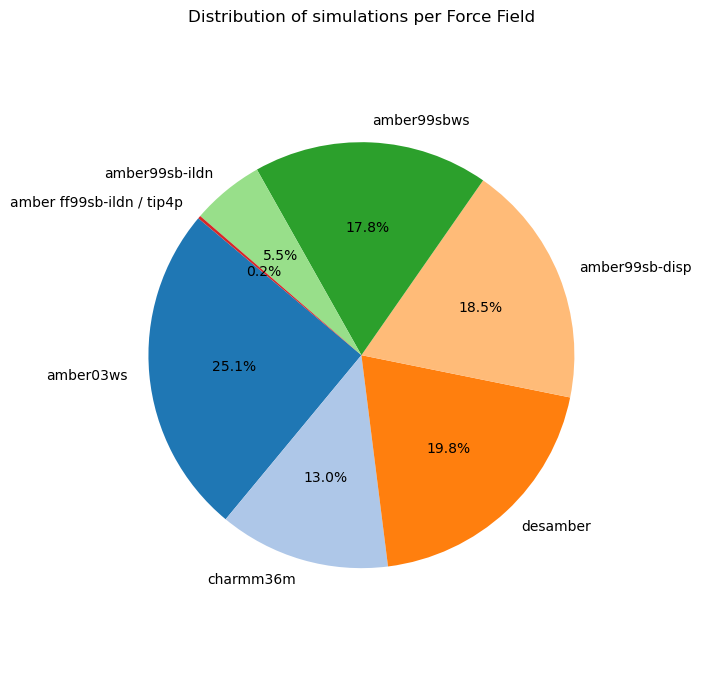

In [6]:
import matplotlib.pyplot as plt

# Use the same system_descriptions dictionary from your previous step
labels = list(system_descriptions.keys())
sizes = list(system_descriptions.values())

# Create pie chart
plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title("Distribution of simulations per Force Field")
plt.axis('equal')  # Equal aspect ratio ensures the pie is circular
plt.tight_layout()
plt.show()

# Sequence information

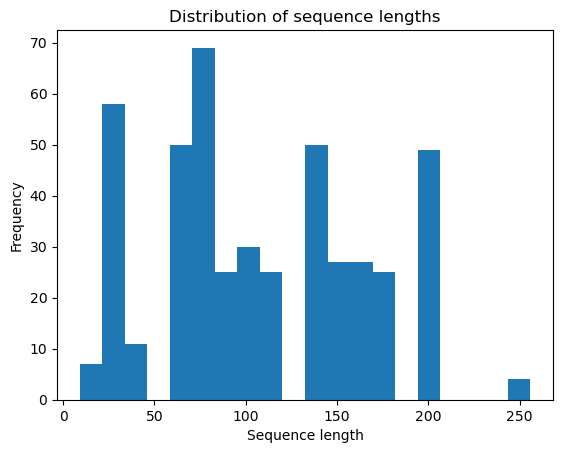

Sequence lengths:
[35, 72, 140, 206, 161, 72, 200, 9, 140, 140, 67, 206, 67, 35, 101, 72, 67, 148, 206, 67, 148, 199, 28, 206, 140, 72, 206, 33, 67, 72, 33, 171, 72, 72, 9, 33, 67, 72, 140, 92, 67, 72, 67, 67, 33, 67, 33, 100, 117, 33, 79, 154, 161, 140, 100, 161, 33, 33, 117, 100, 140, 101, 72, 72, 67, 117, 72, 148, 199, 199, 148, 100, 72, 67, 171, 67, 100, 33, 100, 79, 140, 67, 92, 79, 161, 117, 92, 92, 92, 67, 140, 35, 140, 162, 161, 140, 67, 200, 161, 79, 67, 33, 72, 100, 35, 161, 206, 92, 148, 140, 81, 148, 140, 99, 171, 199, 67, 33, 117, 72, 72, 199, 33, 100, 9, 67, 92, 92, 161, 200, 100, 72, 33, 33, 67, 140, 171, 79, 67, 92, 148, 35, 72, 67, 171, 206, 206, 161, 140, 33, 140, 33, 72, 100, 140, 67, 206, 206, 67, 72, 199, 140, 33, 100, 200, 79, 72, 140, 117, 140, 148, 79, 161, 206, 33, 101, 199, 33, 79, 117, 199, 100, 171, 92, 35, 140, 140, 140, 161, 148, 140, 79, 92, 148, 140, 171, 140, 140, 92, 206, 67, 148, 33, 117, 171, 67, 33, 92, 171, 206, 92, 148, 72, 171, 140, 67, 79, 79, 1

In [7]:
from collections import Counter

sequences = []

for system in systems:
    sequences.append(system['COMPOSITION']['PROTEIN']['SEQUENCE'])

#print(sequences)

# --- 1. Compute sequence lengths ---
lengths = [len(seq) for seq in sequences]

# --- 2. Plot distribution of sequence lengths ---
plt.figure()
plt.hist(lengths, bins=20)
plt.xlabel("Sequence length")
plt.ylabel("Frequency")
plt.title("Distribution of sequence lengths")
plt.show()

# --- 3. Get unique sequences ---
unique_sequences = list(set(sequences))

# --- 4. Count number of unique sequences ---
num_unique_sequences = len(unique_sequences)

# --- 5. (Optional) Count frequency of each sequence ---
sequence_counts = Counter(sequences)

# --- Output results ---
print("Sequence lengths:")
print(lengths)

print("\nUnique sequences:")
print(unique_sequences)

print("\nNumber of unique sequences:")
print(num_unique_sequences)

print("\nSequence counts (frequency):")
print(sequence_counts)

# Disorder information

In [8]:
for system in systems:
    path = databankPath + '/Data/Simulations/' + (system['path'])
    secondary_structure_file = path + '/secondary_structure.yaml'
    with open(secondary_structure_file, "r") as f:
        secondary_structure_data = yaml.safe_load(f)
    print(secondary_structure_data)
    print()

{'10_V': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '11_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '12_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '13_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '14_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '15_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '16_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '17_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '18_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '19_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '1_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '20_K': {'

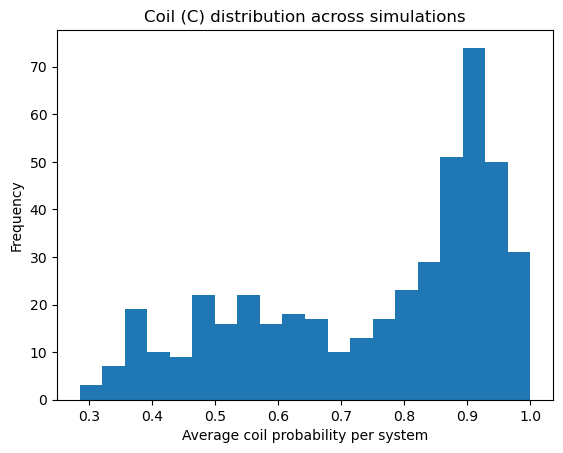

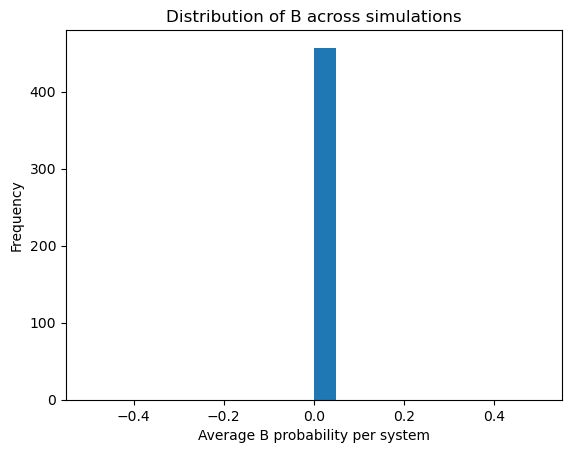

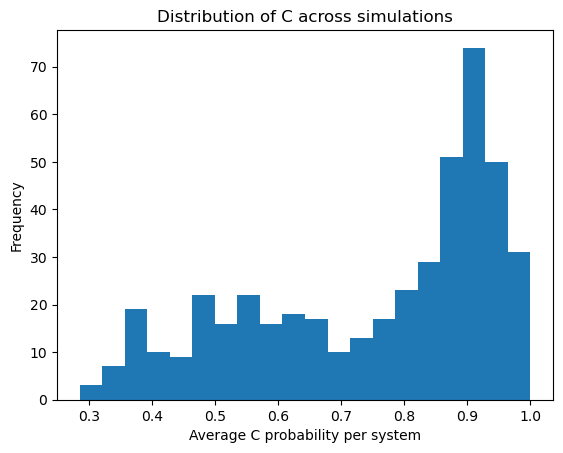

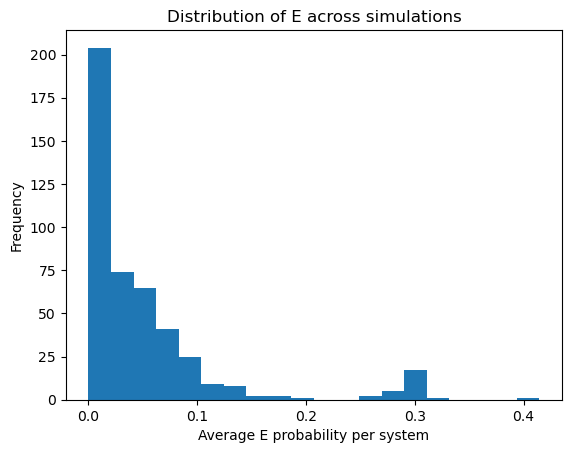

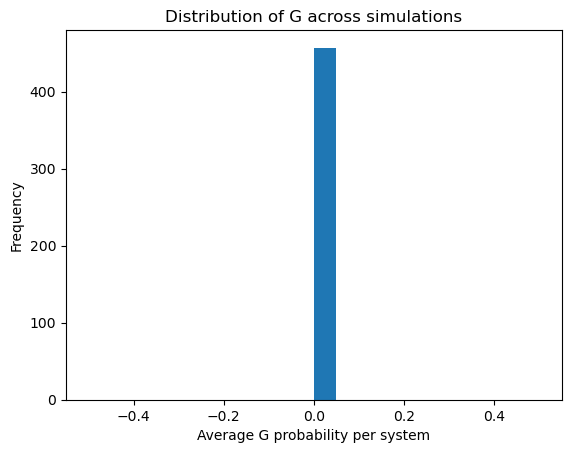

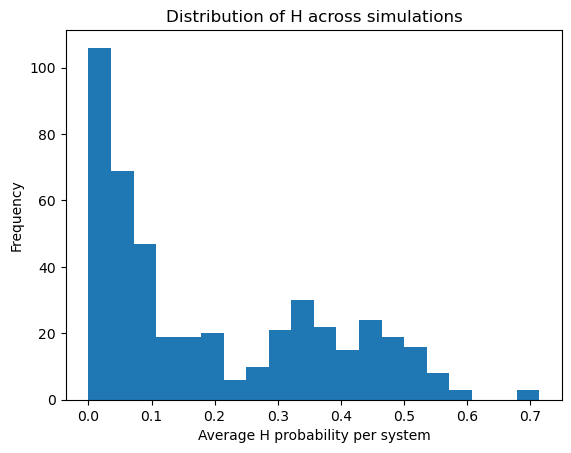

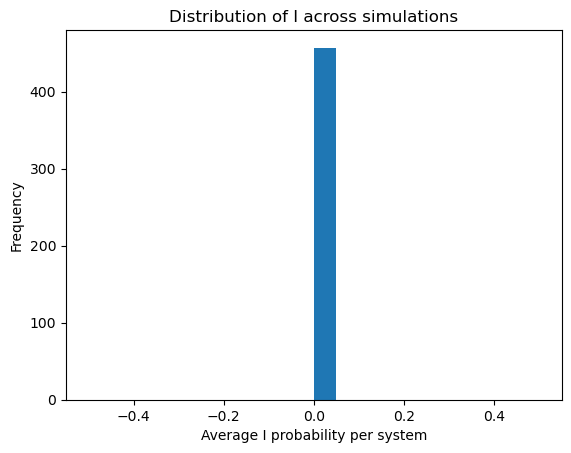

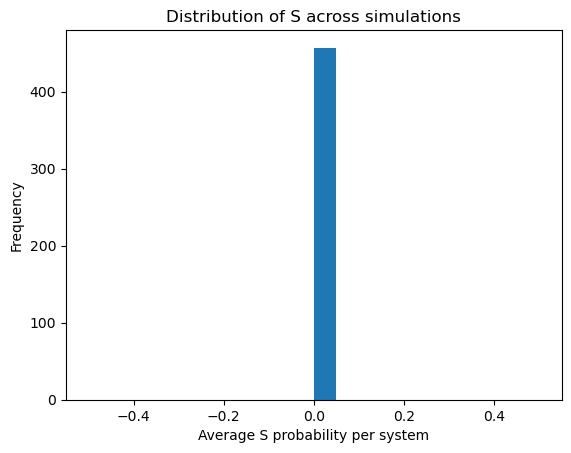

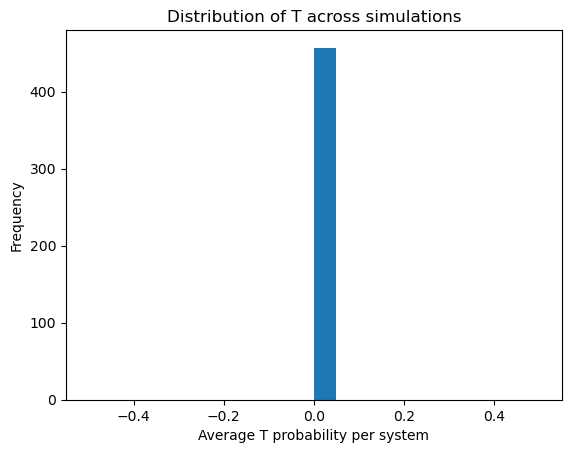

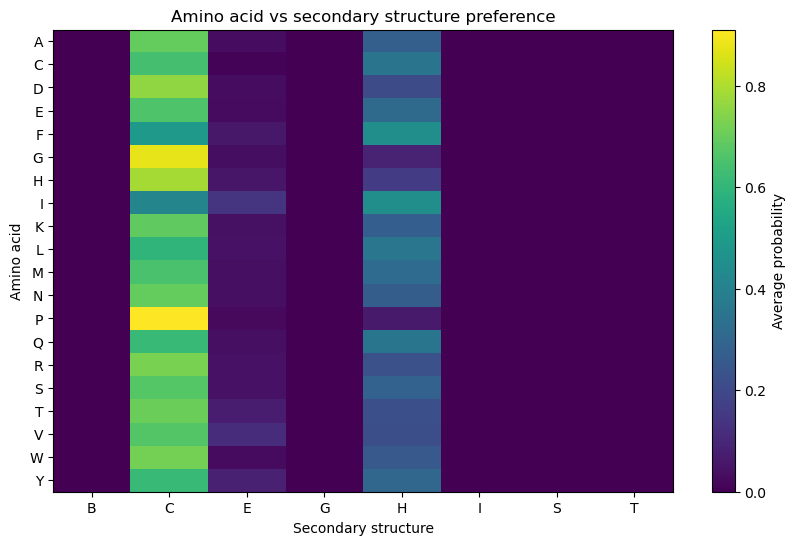

In [8]:
import os
import yaml
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

# --- Storage ---
avg_coil_per_system = []
ss_per_system = defaultdict(list)  
# ss_per_system["C"] = [avg_C_system1, avg_C_system2, ...]

aa_ss_counts = defaultdict(lambda: defaultdict(list))

# --- Loop over systems ---
for system in systems:
    path = os.path.join(databankPath, "Data", "Simulations", system["path"])
    secondary_structure_file = os.path.join(path, "secondary_structure.yaml")

    try:
        with open(secondary_structure_file, "r") as f:
            data = yaml.safe_load(f)
    except FileNotFoundError:
        print(f"Missing: {secondary_structure_file}")
        continue

    # --- per-system averages for each SS type ---
    ss_sums = defaultdict(list)

    for residue, ss_dict in data.items():
        for ss_type, prob in ss_dict.items():
            ss_sums[ss_type].append(prob)

            # AA-level aggregation
            aa = residue.split("_")[1]
            aa_ss_counts[aa][ss_type].append(prob)

    # compute system-level averages
    for ss_type, vals in ss_sums.items():
        ss_per_system[ss_type].append(np.mean(vals))

# =========================
# 📊 1. Coil distribution (existing)
# =========================
plt.figure()
plt.hist(ss_per_system["C"], bins=20)
plt.xlabel("Average coil probability per system")
plt.ylabel("Frequency")
plt.title("Coil (C) distribution across simulations")
plt.show()

# =========================
# 📊 2. Distribution for EACH SS type
# =========================
ss_types = sorted(ss_per_system.keys())

for ss in ss_types:
    plt.figure()
    plt.hist(ss_per_system[ss], bins=20)
    plt.xlabel(f"Average {ss} probability per system")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {ss} across simulations")
    plt.show()

# =========================
# 📊 3. AA vs SS heatmap (same as before)
# =========================

aa_list = sorted(aa_ss_counts.keys())
ss_types_matrix = sorted(next(iter(aa_ss_counts.values())).keys())

matrix = []

for aa in aa_list:
    row = []
    for ss in ss_types_matrix:
        values = aa_ss_counts[aa][ss]
        row.append(np.mean(values) if values else 0)
    matrix.append(row)

matrix = np.array(matrix)

plt.figure(figsize=(10, 6))
plt.imshow(matrix, aspect='auto')
plt.colorbar(label="Average probability")

plt.xticks(range(len(ss_types_matrix)), ss_types_matrix)
plt.yticks(range(len(aa_list)), aa_list)

plt.xlabel("Secondary structure")
plt.ylabel("Amino acid")
plt.title("Amino acid vs secondary structure preference")

plt.show()

In [10]:
def average_coil_probability(data):
    total = 0.0
    count = 0

    for probs in data.values():
        if "C" in probs:
            total += probs["C"]
            count += 1

    return total / count if count > 0 else 0.0


def plot_distribution(values):
    plt.figure()
    plt.hist(values, bins=20)  # adjust bins if needed
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title("Distribution of Values")
    plt.show()

disordered_proteins = []
partially_folded_proteins = []
folded_proteins = []

for system in systems:
    path = databankPath + '/Data/Simulations/' + (system['path'])
    secondary_structure_file = path + '/secondary_structure.yaml'
    with open(secondary_structure_file, "r") as f:
        secondary_structure_data = yaml.safe_load(f)
    coil_probability = average_coil_probability(secondary_structure_data)

    system_name = system['SYSTEM']
    if coil_probability > 0.7 and system_name not in disordered_proteins:
        disordered_proteins.append(system_name)
    if coil_probability > 0.4 and coil_probability < 0.7 and system_name not in partially_folded_proteins:
        partially_folded_proteins.append(system_name)
    if coil_probability < 0.4 and system_name not in folded_proteins:
        folded_proteins.append(system_name)


#plot_distribution(tst)
print(disordered_proteins)
print()
print(partially_folded_proteins)
print()
print(folded_proteins)

['Charged sequence with tris', 'KRS1-72_salt', 'asyn_salt', 'SNAP25_noions', 'KRS1-72', 'Protein linker', 'asyn', 'ChiZ_salt', 'ChiZ1-64', 'Charged sequence with NaCl', 'silk protein', 'icl2', 'Charged protonated sequence with CaCl', 'wrapping silk (AcSp1)', 'Charged sequence with NaCl and phosphate', 'EN2', 'Charged sequence with CaCl', 'Charged protonated sequence with NaCl', 'Charged sequence with CaCl and phosphate', 'TonB', 'Charged sequence protonated peptide', 'TonB low pH with CaCl', 'Charged sequence peptide', 'TonB low pH with NaCl', 'TonB with CaCl, deprotonated']

['CDNF', 'wrapping silk (AcSp1)', 'SNAP25_noions', 'calmodulin', 'MANF', 'EN2', 'asyn_salt', 'asyn', 'TonBCTD', 'silk protein']

['asyn_salt', 'TonBCTD', 'calmodulin', 'SNAP25_noions', 'Calmodulin']


# Plot systems with experimental data available

In [49]:
# Loop over simulations in the Databank
system_IDs_with_cs_data = []
system_IDs_with_sr_data = []

for system in systems:
    if len(system['EXPERIMENT']['chemical_shift']['alignment_score']) > 0 :
        system_IDs_with_cs_data.append(system['ID'])
    if len(system['EXPERIMENT']['spin_relaxation']['alignment_score']) > 0:
        system_IDs_with_sr_data.append(system['ID'])
    #print()

In [50]:
total_number = 0
cs_evaluated = 0
sr_evaluated = 0
both_evaluated = 0

systems_titles_no_sr = [] 
systems_titles_no_cs = [] 

systems_titles_with_sr = [] 
systems_titles_with_cs = [] 


for system in systems:
    sr_value = False
    cs_value = False

    total_number += 1
    
    if system['ID'] in system_IDs_with_sr_data:
        sr_evaluated += 1
        sr_value = True
        if system['SYSTEM'] not in systems_titles_with_sr:
            systems_titles_with_sr.append(system['SYSTEM'])
        
    if system['ID'] not in system_IDs_with_sr_data:
        if system['SYSTEM'] not in systems_titles_no_sr:
            systems_titles_no_sr.append(system['SYSTEM'])
        
    
    if system['ID'] in system_IDs_with_cs_data:
        cs_evaluated += 1
        cs_value = True
        if system['SYSTEM'] not in systems_titles_with_cs:
            systems_titles_with_cs.append(system['SYSTEM'])
    
    if system['ID'] not in system_IDs_with_cs_data:
        if system['SYSTEM'] not in systems_titles_no_cs:
            systems_titles_no_cs.append(system['SYSTEM'])

    if cs_value and sr_value:
        both_evaluated += 1

print('Chemical shifts evaluated: ', round(100*cs_evaluated/total_number), '%,', ' Number of systems: ', cs_evaluated)
print('Spin relaxations evaluated: ', round(100*sr_evaluated/total_number), '%', ' Number of systems: ', sr_evaluated)
print('Both evaluated: ', round(100*both_evaluated/total_number), '%', ' Number of systems: ', both_evaluated)
            
        #print(system['SYSTEM'])

#print(system_IDs_with_cs_data)
#print(system_IDs_with_sr_data)

Chemical shifts evaluated:  34 %,  Number of systems:  151
Spin relaxations evaluated:  56 %  Number of systems:  251
Both evaluated:  34 %  Number of systems:  151


In [51]:
print(systems_titles_no_sr)
print()
print(systems_titles_no_cs)

['Charged sequence with tris', 'SNAP25_noions', 'wrapping silk (AcSp1)', 'Protein linker', 'Charged sequence with NaCl', 'silk protein', 'MANF', 'TonBCTD', 'Charged protonated sequence with CaCl', 'Charged sequence with NaCl and phosphate', 'Charged sequence with CaCl', 'Charged protonated sequence with NaCl', 'Charged sequence with CaCl and phosphate', 'TonB', 'Charged sequence protonated peptide', 'TonB low pH with CaCl', 'Charged sequence peptide', 'TonB low pH with NaCl', 'TonB with CaCl, deprotonated']

['Charged sequence with tris', 'KRS1-72_salt', 'SNAP25_noions', 'KRS1-72', 'wrapping silk (AcSp1)', 'Protein linker', 'ChiZ_salt', 'ChiZ1-64', 'Charged sequence with NaCl', 'silk protein', 'MANF', 'TonBCTD', 'Charged protonated sequence with CaCl', 'Charged sequence with NaCl and phosphate', 'Charged sequence with CaCl', 'Charged protonated sequence with NaCl', 'Charged sequence with CaCl and phosphate', 'TonB', 'Charged sequence protonated peptide', 'TonB low pH with CaCl', 'Charg

In [52]:
print(systems_titles_with_sr)
print()
print(systems_titles_with_cs)

['KRS1-72_salt', 'asyn_salt', 'CDNF', 'KRS1-72', 'asyn', 'ChiZ_salt', 'ChiZ1-64', 'calmodulin', 'icl2', 'EN2', 'Calmodulin']

['asyn_salt', 'CDNF', 'asyn', 'calmodulin', 'icl2', 'EN2', 'Calmodulin']


# Plotting pie diagram of temperatures

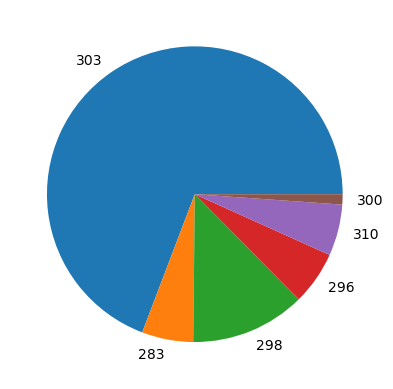

In [53]:
#db_data.pie_temperature()
import collections
temps = [ int(float(system['TEMPERATURE'])) for system in systems]
counter = collections.Counter(temps)
plt.pie(counter.values(),labels=counter.keys());

<Figure size 640x480 with 0 Axes>

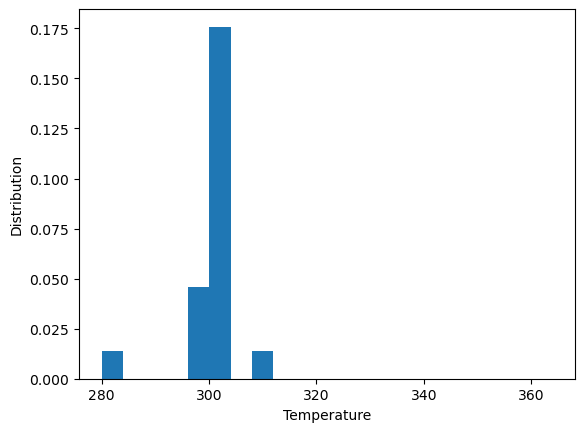

<Figure size 640x480 with 0 Axes>

In [54]:
distTemps = plt.hist(temps, density=True, bins=np.arange(280,365,4))
plt.xlabel('Temperature')
plt.ylabel('Distribution')
plt.figure()

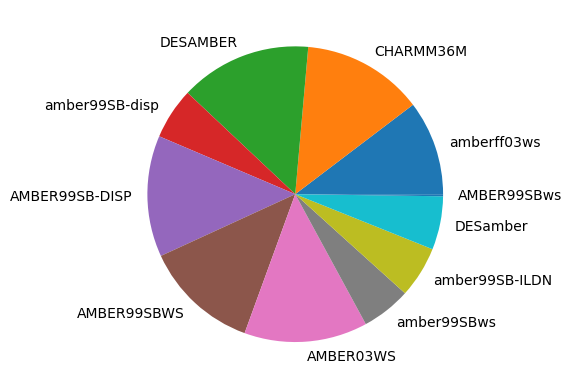

In [55]:

temps = [ s['FF'] for s in systems if 'FF' in s]
counter = collections.Counter(temps)
plt.pie(counter.values(),labels=counter.keys());

{'AMBER99SBws': 1}


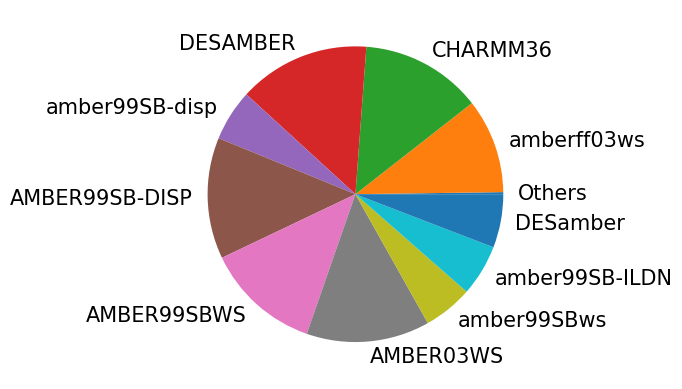

In [56]:
ffs = []

for system in systems:
    try:
        ff = system['FF']
    except:
        print('Force field information missing from' + system['path'])
    
    if 'GROMOS-CKP' in ff or 'gromos-ckp' in ff:
        ffs.append('GROMOS-CKP')
    elif 'Charmm-Drude' in ff:
        ffs.append('Charmm-Drude')
    elif 'Berger' in ff:
        ffs.append('Berger')    
    elif 'Slipids' in ff or 'slipids' in ff:
        ffs.append('Slipids')    
    elif 'lipid17ecc' in ff or 'ECC-lipids' in ff:
        ffs.append('ECClipids')
    elif 'ECC-CHARMM36' in ff:
        ffs.append(ff)
    elif 'CHARMM36' in ff or 'Charmm36' in ff:
        ffs.append('CHARMM36')
    elif 'Lipid14' in ff or 'Lipid17' in ff or 'lipid17' in ff:
        ffs.append('Lipid14/17')
    elif 'Poger' in ff:
        ffs.append('Poger')
    else:
        ffs.append(ff)
    
counter = collections.Counter(ffs)
several = {}
several['Others'] = 0
less = {}
for i in counter:
    if counter[i] > 5:
        several[i] = counter[i]
    else:
        several['Others'] += counter[i] 
        less[i] = counter[i]
#plt.pie(counter.values(),labels=counter.keys(), textprops={'fontsize': 15});
plt.pie(several.values(),labels=several.keys(), textprops={'fontsize': 15});
#plt.savefig('../../../DataBankManuscriptText/Figures/FFpie.pdf', bbox_inches='tight')
print(less)